# 🎓 CUSAT Admissions Chatbot
### Multilingual RAG chatbot powered by **Groq LLM** + **FAISS** + **LangGraph**

Answers questions about the **CUSAT 2026 Admissions Prospectus** in any language.

**Architecture:**
```
User Query (any language)
       │
   [Planner] ─ LLM decides: retrieve or answer_direct
       │
  [Retriever] ─ FAISS similarity search over prospectus chunks
       │
  [Translator] ─ detect source language
       │
   [Answerer] ─ Groq LLM generates answer IN the user's language
```

**Setup:** `pip install groq faiss-cpu pymupdf langgraph pydantic scikit-learn langdetect`


In [ ]:
!pip install groq faiss-cpu pymupdf langgraph pydantic scikit-learn langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 50.1 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=b9622b5d3eaee275bdae8fef7348dd11dc4eed9637ee92f55d76bc6cdc554662
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
!pip install urllib3

In [ ]:
# Install all required packages
import subprocess, sys
pkgs = ["groq", "faiss-cpu", "pymupdf", "langgraph", "pydantic",
        "scikit-learn", "langdetect", "requests"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ All packages installed")


✅ All packages installed


In [ ]:
import os, re, pickle, textwrap, warnings
from pathlib import Path
from typing import Optional

# Install all required packages
import subprocess, sys

In [ ]:
pkgs = ["groq", "faiss-cpu", "pymupdf", "langgraph", "pydantic",
        "scikit-learn", "langdetect", "requests"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ All packages installed")

import os, re, pickle, textwrap, warnings
from pathlib import Path
from typing import Optional

import fitz                          # PyMuPDF
import numpy as np
import faiss
from groq import Groq
from langdetect import detect, DetectorFactory
from pydantic import BaseModel, Field


✅ All packages installed


In [ ]:
# ─── Configuration ────────────────────────────────────────────
PDF_PATH   = Path("Prospectus2026.pdf")
CACHE_FILE = Path("cusat_faiss.pkl")

CHUNK_SIZE = 350    # words per chunk
CHUNK_STEP = 150    # stride (overlap ~57 %)
EMBED_DIM  = 256    # LSA dimensions
TOP_K      = 5      # passages per query

GROQ_MODEL = "llama-3.3-70b-versatile"

# ── Set your Groq API key here (or use env var) ─────────────────
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "YOUR_GROQ_API_KEY_HERE")
print("✅ Config loaded")

✅ Config loaded


In [ ]:
def extract_pdf_text(path: Path) -> list[dict]:
    """Extract text from every page of the PDF using PyMuPDF.
    Returns a list of {page, text} dicts."""
    doc   = fitz.open(str(path))
    pages = []
    for i, page in enumerate(doc):
        text = page.get_text("text").strip()
        if text:
            pages.append({"page": i + 1, "text": text})
    doc.close()
    print(f"✅ Extracted text from {len(pages)} pages")
    return pages


def chunk_pages(pages: list[dict], size: int = CHUNK_SIZE,
                step: int = CHUNK_STEP) -> tuple[list[str], list[dict]]:
    """Sliding-window word chunker.  Returns (chunks, metadata)."""
    chunks, meta = [], []
    for page_info in pages:
        words    = page_info["text"].split()
        page_num = page_info["page"]
        for i in range(0, len(words), step):
            chunk = " ".join(words[i : i + size])
            if len(chunk.strip()) < 60:
                continue
            chunks.append(chunk)
            meta.append({"page": page_num, "offset": i})
    print(f"✅ Created {len(chunks):,} chunks (size={size}, step={step})")
    return chunks, meta


pages         = extract_pdf_text(PDF_PATH)
chunks, chunk_meta = chunk_pages(pages)

✅ Extracted text from 150 pages
✅ Created 370 chunks (size=350, step=150)


In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

class FAISSStore:
    """TF-IDF + LSA -> L2-normalised dense vectors -> FAISS IndexFlatIP (cosine)."""

    def __init__(self, chunks: list[str], meta: list[dict],
                 cache: Path = CACHE_FILE, dim: int = EMBED_DIM):
        if cache.exists():
            print("⚡ Loading FAISS index from cache ...")
            with open(cache, "rb") as f:
                data = pickle.load(f)
            self.vectorizer = data["vectorizer"]
            self.svd        = data["svd"]
            self.dim        = data["dim"]
            self.chunks     = data["chunks"]
            self.meta       = data["meta"]
            vecs            = data["vectors"]
            self.index      = faiss.IndexFlatIP(self.dim)
            self.index.add(vecs)
        else:
            self._build(chunks, meta, cache, dim)
        print(f"✅ FAISS ready — {self.index.ntotal:,} vectors, dim={self.dim}")

    def _build(self, chunks, meta, cache, dim):
        print("🔨 Fitting TF-IDF ...")
        self.chunks     = chunks
        self.meta       = meta
        self.vectorizer = TfidfVectorizer(
            max_features=80_000, ngram_range=(1, 2), sublinear_tf=True
        )
        X_sp = self.vectorizer.fit_transform(chunks)

        real_dim    = min(dim, X_sp.shape[1] - 1, X_sp.shape[0] - 1)
        self.dim    = real_dim
        print(f"🔨 Fitting LSA (dim={real_dim}) ...")
        self.svd    = TruncatedSVD(n_components=real_dim, random_state=42)
        X_dense     = self.svd.fit_transform(X_sp).astype(np.float32)
        faiss.normalize_L2(X_dense)

        self.index  = faiss.IndexFlatIP(real_dim)
        self.index.add(X_dense)

        with open(cache, "wb") as f:
            pickle.dump({
                "vectorizer": self.vectorizer, "svd": self.svd,
                "dim": self.dim, "chunks": self.chunks,
                "meta": self.meta, "vectors": X_dense,
            }, f)
        print("✅ Index built & cached")

    def _embed(self, text: str) -> np.ndarray:
        x = self.svd.transform(
            self.vectorizer.transform([text])
        ).astype(np.float32)
        faiss.normalize_L2(x)
        return x

    def search(self, query: str, k: int = TOP_K) -> list[dict]:
        scores, idxs = self.index.search(self._embed(query), k)
        return [
            {
                "text":   self.chunks[i],
                "score":  float(scores[0][r]),
                "page":   self.meta[i]["page"],
            }
            for r, i in enumerate(idxs[0]) if i != -1
        ]

# Remove old cache if PDF was just downloaded fresh
vector_store = FAISSStore(chunks, chunk_meta)


🔨 Fitting TF-IDF ...
🔨 Fitting LSA (dim=256) ...
✅ Index built & cached
✅ FAISS ready — 370 vectors, dim=256


In [ ]:
from google.colab import userdata

class GroqLLM:
    def __init__(self, model: str = GROQ_MODEL, api_key: str = userdata.get('GROQ_API_KEY')):
        if api_key == None:
            raise ValueError(
                "Please set GROQ_API_KEY — "
                "get a free key at https://console.groq.com"
            )
        self.client = Groq(api_key=api_key)
        self.model  = model

    def chat(self, system: str, user: str, max_tokens: int = 700) -> str:
        resp = self.client.chat.completions.create(
            model      = self.model,
            max_tokens = max_tokens,
            messages   = [
                {"role": "system", "content": system},
                {"role": "user",   "content": user},
            ],
        )
        return resp.choices[0].message.content.strip()

llm = GroqLLM()
print("✅ Groq LLM ready —", GROQ_MODEL)


LANGUAGE_NAMES = {
    "en": "English",    "ml": "Malayalam",  "hi": "Hindi",
    "ta": "Tamil",      "te": "Telugu",     "kn": "Kannada",
    "fr": "French",     "de": "German",     "es": "Spanish",
    "zh-cn": "Chinese", "ar": "Arabic",     "ja": "Japanese",
}

def detect_language(text: str) -> tuple[str, str]:
    """Returns (lang_code, lang_name)."""
    try:
        code = detect(text)
    except Exception:
        code = "en"
    name = LANGUAGE_NAMES.get(code, code.upper())
    return code, name

# Quick test
code, name = detect_language("പ്രവേശന പരീക്ഷ എപ്പോഴാണ്?")
print(f"✅ Language detection works — detected: {name} ({code})")



✅ Groq LLM ready — llama-3.3-70b-versatile
✅ Language detection works — detected: Malayalam (ml)


✅ Prompts defined
✅ Graph nodes defined
✅ LangGraph compiled



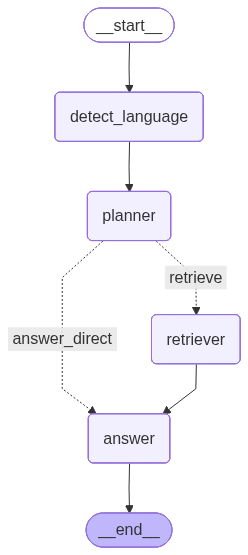


────────────────────────────────────────────────────────────
Q: What are the eligibility criteria for B.Tech admission at CUSAT?
  [lang]      English (en)
  [planner]   retrieve
  [retriever] top score=0.363  page=109
A: The provided context does not contain the eligibility criteria for B.Tech admission at CUSAT. However, it does mention the eligibility criteria for B.Tech Lateral Entry programs, which are as follows: 

For most B.Tech Lateral Entry programs, the minimum qualification required is a three-year diploma in engineering/technology with not less than 60% marks. For Instrumentation and Control Engineering, candidates should have a three-year diploma in Instrumentation or Electronics with not less than 60% marks. 

For more information on B.Tech admission eligibility criteria, please refer to the relevant section of the CUSAT 2026 Admissions Prospectus, which is not provided in the given context.
────────────────────────────────────────────────────────────

─────────────────

'As per page 87 of the prospectus, the seat allocation is based on the reservation policy of the Government of India. Additionally, as per page 32, relaxations in marks shall be followed for candidates belonging to SC/ST and socially and educationally backward classes as prescribed by the University. However, the exact details of the reservation policy are not specified in the provided context.'

In [ ]:
from langgraph.graph import StateGraph, END
# ─── State schema ─────────────────────────────────────────────
class ChatState(BaseModel):
    query:       str            = Field(...)
    lang_code:   str            = "en"
    lang_name:   str            = "English"
    action:      Optional[str]  = None
    docs:        Optional[list] = None
    answer:      Optional[str]  = None

# ─── Prompts ──────────────────────────────────────────────────
PLANNER_SYS = textwrap.dedent("""
    You are a routing assistant for a CUSAT admissions chatbot.
    The user may write in any language.
    Decide whether the question needs searching the CUSAT 2026 Prospectus
    for specific details (action = "retrieve") or can be answered from
    general knowledge (action = "answer_direct").

    Rules:
    - Admission dates, fees, eligibility, courses, documents, reservations,
      exam schedules, hostel info → retrieve
    - Greetings, general knowledge, off-topic questions → answer_direct

    Reply with ONLY one word: retrieve   OR   answer_direct
""").strip()

ANSWER_SYS = textwrap.dedent("""
    You are a helpful admissions assistant for Cochin University of Science
    and Technology (CUSAT).  You answer questions STRICTLY based on the
    provided context excerpts from the CUSAT 2026 Admissions Prospectus.

    CRITICAL RULE: You MUST reply in {lang_name} ({lang_code}).
    If the user wrote in Malayalam, reply in Malayalam.
    If in Hindi, reply in Hindi. Match the user's language exactly.

    Guidelines:
    - Be concise and factual.
    - Quote page numbers when helpful (e.g., "as per page 12 of the prospectus").
    - If the context does not contain enough information, say so clearly in {lang_name}.
    - Do NOT make up fees, dates, or eligibility criteria.
""").strip()

FALLBACK_SYS = textwrap.dedent("""
    You are a helpful assistant for CUSAT admissions.
    Reply in {lang_name} ({lang_code}).
    If the question is off-topic, politely redirect to CUSAT admissions.
""").strip()

print("✅ Prompts defined")


def node_detect_language(state: ChatState) -> ChatState:
    code, name          = detect_language(state.query)
    state.lang_code     = code
    state.lang_name     = name
    print(f"  [lang]      {name} ({code})")
    return state

def node_planner(state: ChatState) -> ChatState:
    # Translate query to English for routing (Groq handles it)
    routing_prompt = (
        f"User question (may be in {state.lang_name}): {state.query}\n\n"
        "Route this: reply ONLY with 'retrieve' or 'answer_direct'."
    )
    decision       = llm.chat(PLANNER_SYS, routing_prompt, max_tokens=8)
    state.action   = "retrieve" if "retrieve" in decision.lower() else "answer_direct"
    print(f"  [planner]   {state.action}")
    return state

def node_retrieve(state: ChatState) -> ChatState:
    # Search in English-transliterated query for better TF-IDF recall
    results      = vector_store.search(state.query, k=TOP_K)
    state.docs   = results
    if results:
        print(f"  [retriever] top score={results[0]['score']:.3f}  page={results[0]['page']}")
    return state

def node_answer(state: ChatState) -> ChatState:
    sys_prompt = ANSWER_SYS.format(
        lang_name=state.lang_name, lang_code=state.lang_code
    ) if state.docs else FALLBACK_SYS.format(
        lang_name=state.lang_name, lang_code=state.lang_code
    )

    if state.docs:
        passages = "\n\n".join(
            f"[Page {d['page']} | relevance {d['score']:.2f}]\n{d['text']}"
            for d in state.docs
        )
        user_msg = (
            f"Context from CUSAT 2026 Prospectus:\n{passages}\n\n"
            f"Question ({state.lang_name}): {state.query}"
        )
    else:
        user_msg = state.query

    state.answer = llm.chat(sys_prompt, user_msg, max_tokens=700)
    return state

print("✅ Graph nodes defined")


graph = StateGraph(ChatState)

graph.add_node("detect_language", node_detect_language)
graph.add_node("planner",         node_planner)
graph.add_node("retriever",       node_retrieve)
graph.add_node("answer",          node_answer)

graph.set_entry_point("detect_language")
graph.add_edge("detect_language", "planner")

graph.add_conditional_edges(
    "planner",
    lambda s: s.action,
    {"retrieve": "retriever", "answer_direct": "answer"},
)
graph.add_edge("retriever", "answer")
graph.add_edge("answer",    END)

app = graph.compile()
print("✅ LangGraph compiled")
print()

# Draw the graph
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph: detect_language -> planner -> [retriever?] -> answer -> END")

def ask(question: str, verbose: bool = True) -> str:
    """Run the RAG pipeline and return the answer."""
    if verbose:
        print(f"\n{'─'*60}")
        print(f"Q: {question}")
    result = app.invoke({"query": question})
    answer = result["answer"]
    if verbose:
        print(f"A: {answer}")
        print(f"{'─'*60}")
    return answer


# ── Demo: English ──────────────────────────────────────────────
ask("What are the eligibility criteria for B.Tech admission at CUSAT?")


# ── Demo: Malayalam ────────────────────────────────────────────
ask("CUSAT-ൽ MBA പ്രോഗ്രാമിന്റെ ഫീസ് എത്രയാണ്?")


# ── Demo: Hindi ────────────────────────────────────────────────
ask("CUSAT में प्रवेश के लिए आवेदन कैसे करें?")


# ── Demo: Tamil ────────────────────────────────────────────────
ask("CUSAT இல் விண்ணப்பிக்க கடைசி தேதி என்ன?")


# ── Demo: Important dates (English) ───────────────────────────
ask("What are the important dates for CUSAT CAT 2026?")


# ── Demo: Reservation policy ───────────────────────────────────
ask("What is the reservation policy for SC/ST candidates at CUSAT?")






In [ ]:
!pip install markdown


In [ ]:

# ── Interactive Chat (run this cell for a live session) ────────
print("CUSAT 2026 Admissions Chatbot")
print("Type your question in any language. Type 'quit' to exit.\n")

while True:
    try:
        q = input("You: ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\n👋 Goodbye!")
        break
    if not q:
        continue
    if q.lower() in {"quit", "exit", "bye", "q"}:
        print("👋 Goodbye!")
        break
    ask(q)

CUSAT 2026 Admissions Chatbot
Type your question in any language. Type 'quit' to exit.

You: Hello

────────────────────────────────────────────────────────────
Q: Hello
  [lang]      NO (no)
  [planner]   answer_direct
A: Hello. How can I help you with CUSAT admissions?
────────────────────────────────────────────────────────────
You: Enik 18 years aanu age, can I go forward with admissions into 3rd year btech?

────────────────────────────────────────────────────────────
Q: Enik 18 years aanu age, can I go forward with admissions into 3rd year btech?
  [lang]      English (en)
  [planner]   retrieve
  [retriever] top score=0.281  page=11
A: As per page 11 of the prospectus, CUSAT offers Lateral Entry to 3rd semester of B.Tech. Programme for candidates with a 3-Year Engineering Diploma. However, the prospectus does not mention a specific age limit for this programme. It is recommended that you check the eligibility criteria and other requirements for the programme you are interested i

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import markdown # Import the markdown library

# Initialize an output widget to display the chat history
output = widgets.Output()

# Initialize a text input widget for the user
text_input = widgets.Text(
    value='',
    placeholder='Type your message here...',
    description='You:',
    disabled=False
)

# HTML template for a single chat message
def format_message_html(sender, message, is_user):
    if is_user:
        bg_color = "#333333" # Dark background for user
        alignment = "flex-end"
    else:
        bg_color = "#444444" # Slightly different dark background for chatbot
        alignment = "flex-start"

    text_color = "#FFFFFF" # White text for both

    # Convert markdown message to HTML
    html_message = markdown.markdown(message)

    return f"""
    <div style="display: flex; justify-content: {alignment}; margin-bottom: 10px;">
        <div style="max-width: 80%; padding: 10px; background-color: {bg_color}; border-radius: 10px; box-shadow: 0 1px 3px rgba(0,0,0,0.1);">
            <strong style="color: {text_color};">{sender}:</strong> <span style="color: {text_color};">{html_message}</span>
        </div>
    </div>
    """

# Function to handle user input and generate chatbot response
def on_submit(sender):
    with output:
        # Display user message
        user_message = text_input.value
        display(HTML(format_message_html("You", user_message, True)))
        text_input.value = '' # Clear the input box

        # Get chatbot response using the 'ask' function
        # Modify the 'ask' function to return the answer directly without printing, or capture its output
        # For simplicity, let's assume 'ask' can be adapted or its internal logic can be used here
        # If 'ask' prints, we need to capture stdout. Assuming it returns the string.
        chatbot_response = ask(user_message, verbose=False) # verbose=False to prevent duplicate printing

        # Display chatbot message
        display(HTML(format_message_html("Chatbot", chatbot_response, False)))

# Link the text input's submission to the on_submit function
text_input.on_submit(on_submit)

# Initial chat welcome message
with output:
    display(HTML("<h3 style=\"text-align: center; color: #FFFFFF; font-family: sans-serif; background-color: #222222; padding: 10px; border-radius: 5px;\">Live CUSAT Admissions Chatbot</h3>"))
    display(HTML(format_message_html("Chatbot", "Hello! I'm here to help you with CUSAT 2026 Admissions. Ask me anything! You can now use **markdown** in your messages.", False)))

# Display the input and output widgets
display(output, text_input)

Output()

Text(value='', description='You:', placeholder='Type your message here...')

* Use Hugging face Sentence transformer to Embed rather than TFIDF
* Update with the Baselian Prospectus
* Add dictation and build a web front end for the same
* Make it so that it is seamless
* Try implementing this using OpenAI Whisper

